In [1]:
import numpy as np
import matplotlib.pyplot as plt

def wright_fisher_with_selection(N, s, p0, n_generations):
    """
    N: population size
    s: selection coefficient
    p0: initial frequency of A
    n_generations: how long to run
    """
    p = p0
    trajectory = [p]
    
    for _ in range(n_generations):
        if p == 0 or p == 1:
            break  # absorbed
            
        # Step 1: compute fitness-adjusted frequency
        k = round(p * N)
        p_star = (k * (1 + s)) / (N + k * s)
        
        # Step 2: binomial sample
        k_new = np.random.binomial(N, p_star)
        p = k_new / N
        trajectory.append(p)
    
    return trajectory

def estimate_fixation_prob(N, s, p0, n_simulations):
    """
    Estimate φ(p0) by running many simulations
    """
    fixations = 0
    for _ in range(n_simulations):
        traj = wright_fisher_with_selection(N, s, p0, 
                                           n_generations=10*N)
        if traj[-1] == 1.0:
            fixations += 1
    return fixations / n_simulations

def theoretical_fixation_prob(N, s, p0):
    """
    Kimura's formula
    """
    if s == 0:
        return p0
    num = 1 - np.exp(-2 * N * s * p0)
    den = 1 - np.exp(-2 * N * s)
    return num / den

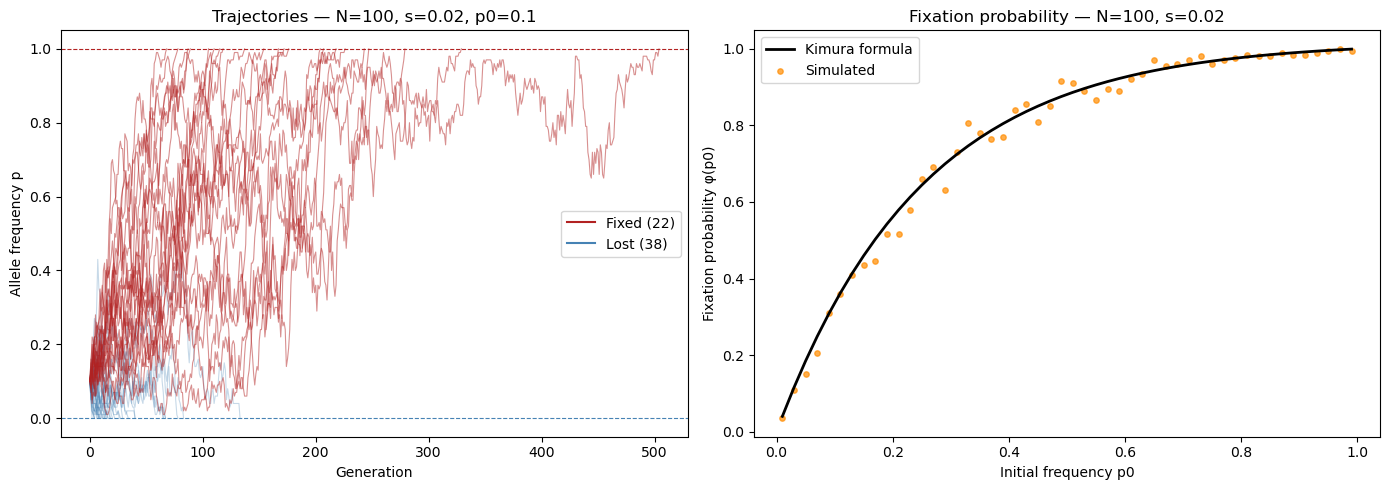

Simulated fixation prob at p0=0.1: 0.367
Theoretical fixation prob at p0=0.1: 0.336


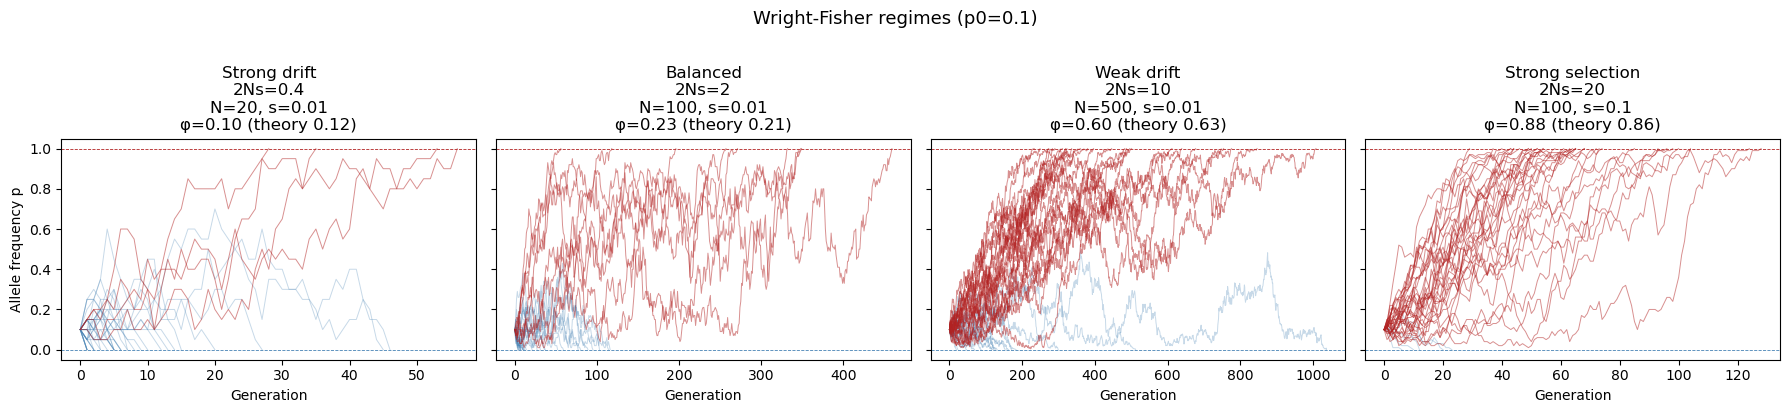

In [3]:
def plot_trajectories(N, s, p0, n_simulations=50, n_generations=None):
    """
    Run many simulations and plot all trajectories, coloring
    by whether they fixed or were lost.
    """
    if n_generations is None:
        n_generations = 10 * N

    fixed_trajs = []
    lost_trajs = []

    for _ in range(n_simulations):
        traj = wright_fisher_with_selection(N, s, p0, n_generations)
        if traj[-1] == 1.0:
            fixed_trajs.append(traj)
        else:
            lost_trajs.append(traj)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- left plot: all trajectories ---
    ax = axes[0]
    for traj in lost_trajs:
        ax.plot(traj, color='steelblue', alpha=0.3, linewidth=0.8)
    for traj in fixed_trajs:
        ax.plot(traj, color='firebrick', alpha=0.5, linewidth=0.8)

    # legend proxies
    from matplotlib.lines import Line2D
    legend = [
        Line2D([0], [0], color='firebrick', label=f'Fixed ({len(fixed_trajs)})'),
        Line2D([0], [0], color='steelblue', label=f'Lost ({len(lost_trajs)})')
    ]
    ax.legend(handles=legend)
    ax.axhline(1.0, color='firebrick', linestyle='--', linewidth=0.8)
    ax.axhline(0.0, color='steelblue', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Generation')
    ax.set_ylabel('Allele frequency p')
    ax.set_title(f'Trajectories — N={N}, s={s}, p0={p0}')
    ax.set_ylim(-0.05, 1.05)

    # --- right plot: fixation probability vs theory ---
    ax2 = axes[1]
    p0_range = np.linspace(0.01, 0.99, 50)
    theory = [theoretical_fixation_prob(N, s, p) for p in p0_range]
    simulated = [estimate_fixation_prob(N, s, p, n_simulations=200) for p in p0_range]

    ax2.plot(p0_range, theory, color='black', linewidth=2, label='Kimura formula')
    ax2.scatter(p0_range, simulated, color='darkorange', s=15, alpha=0.7, label='Simulated')
    ax2.set_xlabel('Initial frequency p0')
    ax2.set_ylabel('Fixation probability φ(p0)')
    ax2.set_title(f'Fixation probability — N={N}, s={s}')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    sim_phi = len(fixed_trajs) / n_simulations
    theory_phi = theoretical_fixation_prob(N, s, p0)
    print(f"Simulated fixation prob at p0={p0}: {sim_phi:.3f}")
    print(f"Theoretical fixation prob at p0={p0}: {theory_phi:.3f}")


def plot_regime_comparison(p0=0.1, n_simulations=40):
    """
    Plot trajectories across 4 different N/s regimes side by side
    to show how drift vs selection balance changes.
    """
    regimes = [
        (20,   0.01, "Strong drift\n2Ns=0.4"),
        (100,  0.01, "Balanced\n2Ns=2"),
        (500,  0.01, "Weak drift\n2Ns=10"),
        (100,  0.1,  "Strong selection\n2Ns=20"),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

    for ax, (N, s, label) in zip(axes, regimes):
        n_gen = 10 * N
        fixed, lost = [], []
        for _ in range(n_simulations):
            traj = wright_fisher_with_selection(N, s, p0, n_gen)
            (fixed if traj[-1] == 1.0 else lost).append(traj)

        for traj in lost:
            ax.plot(traj, color='steelblue', alpha=0.3, linewidth=0.7)
        for traj in fixed:
            ax.plot(traj, color='firebrick', alpha=0.5, linewidth=0.7)

        phi_sim = len(fixed) / n_simulations
        phi_theory = theoretical_fixation_prob(N, s, p0)
        ax.set_title(f'{label}\nN={N}, s={s}\nφ={phi_sim:.2f} (theory {phi_theory:.2f})')
        ax.set_xlabel('Generation')
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(1.0, color='firebrick', linestyle='--', linewidth=0.6)
        ax.axhline(0.0, color='steelblue', linestyle='--', linewidth=0.6)

    axes[0].set_ylabel('Allele frequency p')
    plt.suptitle(f'Wright-Fisher regimes (p0={p0})', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


# --- run it ---
plot_trajectories(N=100, s=0.02, p0=0.1, n_simulations=60)
plot_regime_comparison(p0=0.1, n_simulations=40)